# Loading lab reference data

In [5]:
import pandas as pd
import os

path = "../data/raw/3_laboratory_measurements"

lab_data_p = pd.read_csv(os.path.join(path, "sample_p01-p06.csv"), index_col=0)
lab_data_s = pd.read_csv(os.path.join(path, "sample_s01-s24.csv"), index_col=0)
lab_data_s["tss_mg_l"] = lab_data_s["ss_04u_mg_l"] + lab_data_s["ss_14u_mg_l"]

# Samples from the July campaign

In [6]:
lab_data_p

,tur_raw_ntu,tss_raw_mgl,doc_04u_mg_l,tdn_04u_mg_l,po4p_04u_mg_l,so4s_04umg_l,nh4n_04u_mg_l
sample,,,,,,,
p01,3.670,5.4,35.4,21.6,0.95,80.0,7.5
p02,5.330,11.0,15.0,37.4,1.61,85.8,23.9
p03,7.595,16.2,22.0,54.7,2.58,90.6,38.5
p04,5.385,8.4,15.4,30.0,1.81,94.1,15.5
p05,11.900,19.0,35.3,34.3,2.16,91.4,19.0
p06,13.400,21.7,65.6,39.0,1.95,91.2,22.0


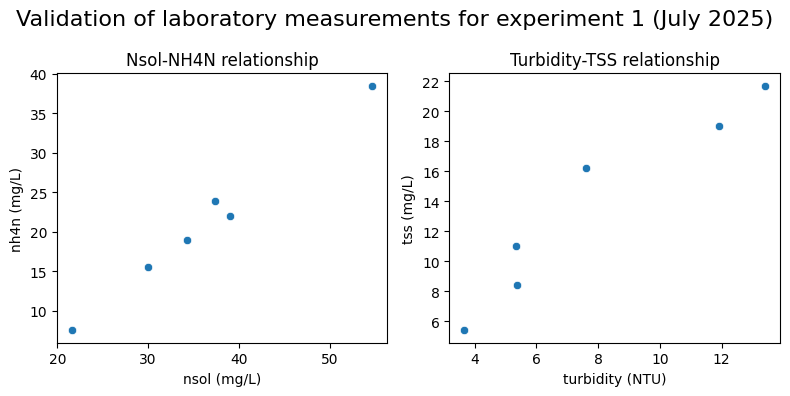

In [7]:
# plot nsol_mg_l-nh4n_mg_l relationship
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize =(8, 4))

sns.scatterplot(ax=ax[0], data=lab_data_p, x="tdn_04u_mg_l", y="nh4n_04u_mg_l")
ax[0].set_xlabel("nsol (mg/L)")
ax[0].set_ylabel("nh4n (mg/L)")
ax[0].set_title("Nsol-NH4N relationship")
sns.scatterplot(ax=ax[1], data=lab_data_p, x="tur_raw_ntu", y="tss_raw_mgl")
ax[1].set_xlabel("turbidity (NTU)")
ax[1].set_ylabel("tss (mg/L)")
ax[1].set_title("Turbidity-TSS relationship")

fig.suptitle("Validation of laboratory measurements for experiment 1 (July 2025)", fontsize=16)
plt.tight_layout()
plt.show()

<Axes: >

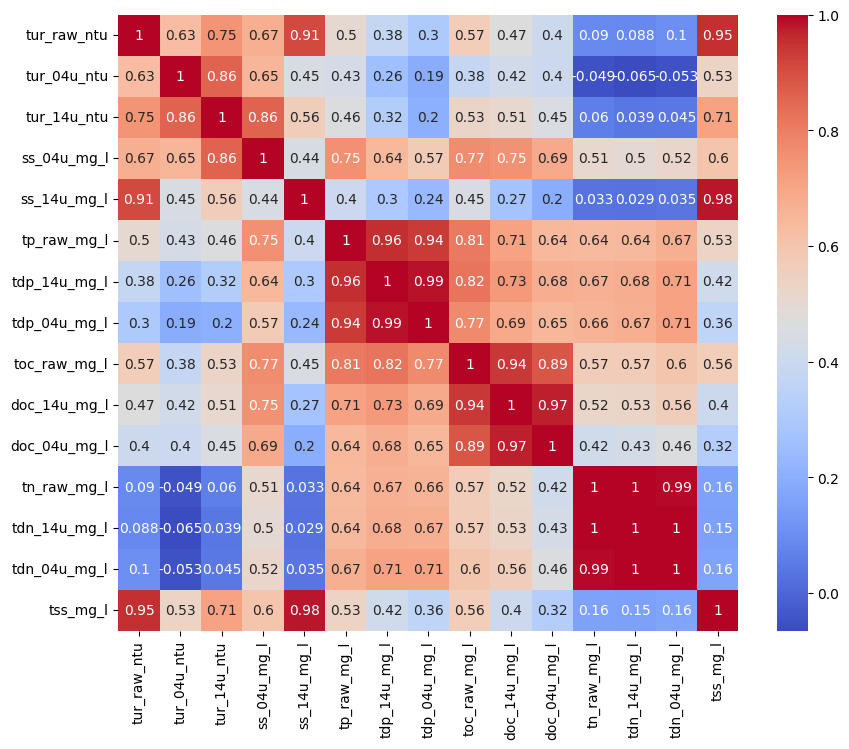

In [8]:
# correlation table lab_data_p.corr() as heatmap with values

lab_data_s = pd.read_csv(os.path.join(path, "sample_s01-s24.csv"), index_col=0)
lab_data_s["tss_mg_l"] = lab_data_s["ss_04u_mg_l"] + lab_data_s["ss_14u_mg_l"]

plt.figure(figsize=(10, 8))
sns.heatmap(lab_data_s.corr(), annot=True, cmap="coolwarm")


# Samples from the November Campaign

In [12]:
lab_data_s.head()

,tur_raw_ntu,tur_04u_ntu,tur_14u_ntu,ss_04u_mg_l,ss_14u_mg_l,tp_raw_mg_l,tdp_14u_mg_l,tdp_04u_mg_l,toc_raw_mg_l,doc_14u_mg_l,doc_04u_mg_l,tn_raw_mg_l,tdn_14u_mg_l,tdn_04u_mg_l,tss_mg_l
sample,,,,,,,,,,,,,,,
s01,3.55,0.29,0.79,1.45,4.05,0.24,0.19,0.17,19.7,14.8,14.3,16.7,15.4,13.90,5.50
s02,6.70,0.62,2.89,NaN,8.30,0.33,0.24,0.14,39.7,25.8,24.8,12.5,10.8,8.54,NaN
s03,8.84,0.55,1.92,2.28,14.39,0.43,0.29,0.25,46.8,18.3,19.7,15.7,14.7,12.80,16.67
s04,3.43,0.42,0.94,1.90,4.20,0.40,0.33,0.32,35.6,27.5,26.7,30.5,28.9,27.50,6.10
s05,10.70,0.51,2.03,2.43,15.60,0.55,0.40,0.35,61.4,32.0,26.9,34.6,33.7,31.00,18.03


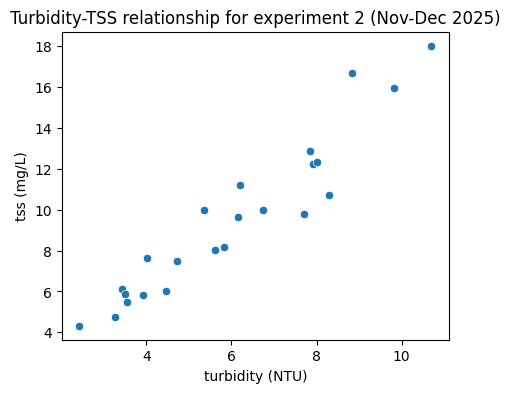

In [10]:
#experiment s: plot tss_mgl-turbidity relationship
plt.figure(figsize=(5, 4))
sns.scatterplot(data=lab_data_s, x="tur_raw_ntu", y="tss_mg_l")
plt.xlabel("turbidity (NTU)")
plt.ylabel("tss (mg/L)")
plt.title("Turbidity-TSS relationship for experiment 2 (Nov-Dec 2025)")
plt.show()


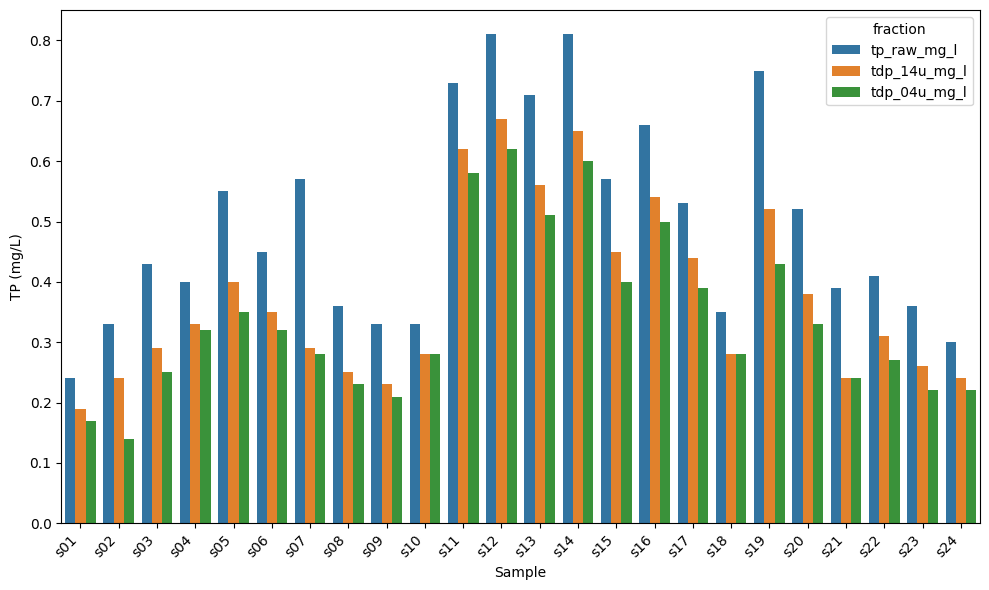

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

lab_data_s = pd.read_csv(os.path.join(path, "sample_s01-s24.csv"), index_col=0)
lab_data_s["tss_mg_l"] = lab_data_s["ss_04u_mg_l"] + lab_data_s["ss_14u_mg_l"]

# reset index so samples become a column
df = lab_data_s.reset_index(names="sample")

# reshape to long format
df_long = df.melt(
    id_vars="sample",
    value_vars=["tp_raw_mg_l", "tdp_14u_mg_l", "tdp_04u_mg_l"],
    var_name="fraction",
    value_name="tp_mg_l"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="sample",
    y="tp_mg_l",
    hue="fraction"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("TP (mg/L)")
plt.xlabel("Sample")
plt.tight_layout()
plt.show()



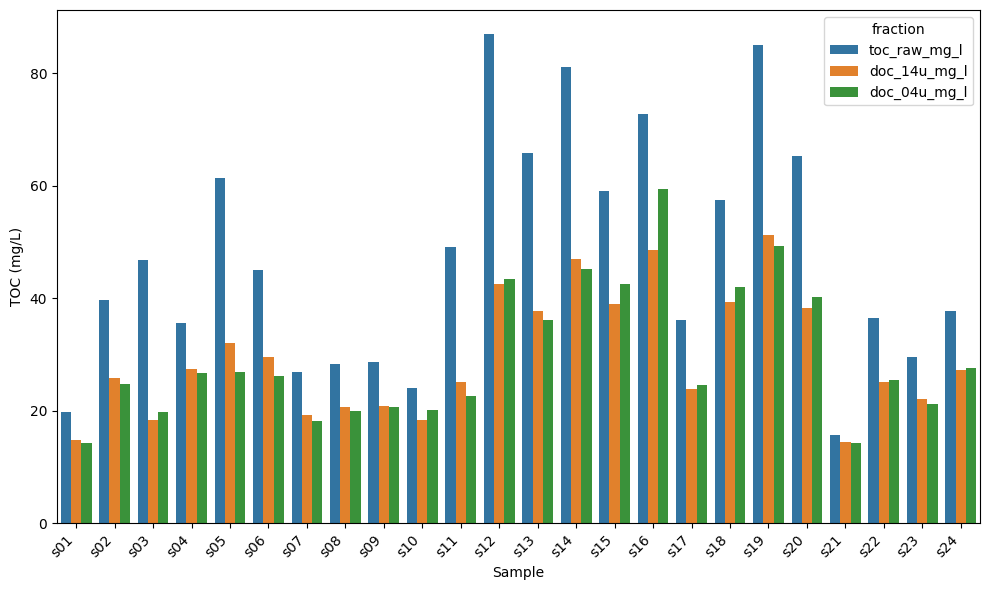

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

lab_data_s = pd.read_csv(os.path.join(path, "sample_s01-s24.csv"), index_col=0)

# reset index so samples become a column
df = lab_data_s.reset_index(names="sample")

# reshape to long format (TN)
df_long = df.melt(
    id_vars="sample",
    value_vars=["toc_raw_mg_l", "doc_14u_mg_l", "doc_04u_mg_l"],
    var_name="fraction",
    value_name="toc"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="sample",
    y="toc",
    hue="fraction"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("TOC (mg/L)")
plt.xlabel("Sample")
plt.tight_layout()
plt.show()


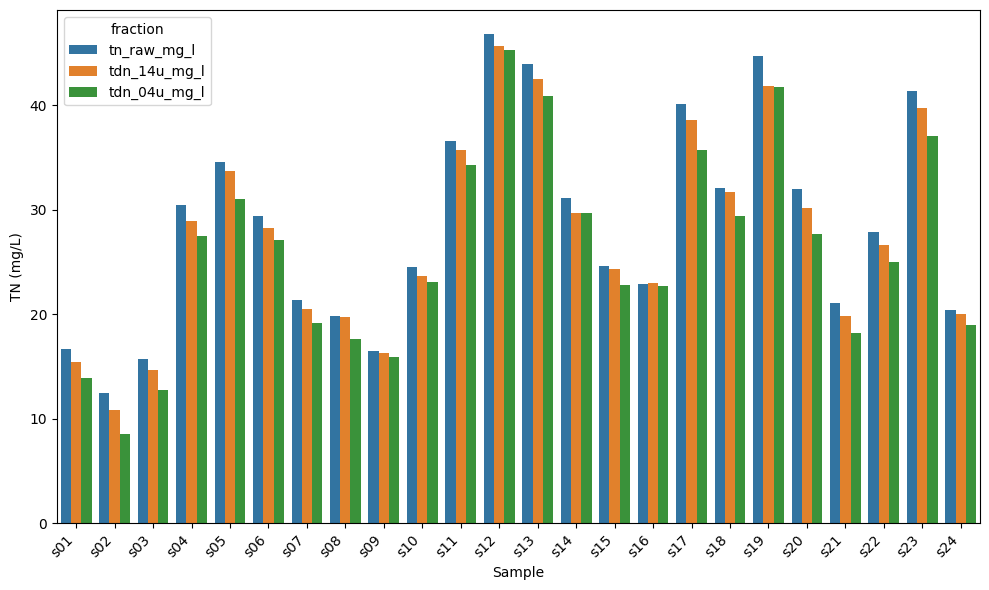

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

lab_data_s = pd.read_csv(os.path.join(path, "sample_s01-s24.csv"), index_col=0)

# reset index so samples become a column
df = lab_data_s.reset_index(names="sample")

# reshape to long format (TN)
df_long = df.melt(
    id_vars="sample",
    value_vars=["tn_raw_mg_l", "tdn_14u_mg_l", "tdn_04u_mg_l"],
    var_name="fraction",
    value_name="tn"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="sample",
    y="tn",
    hue="fraction"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("TN (mg/L)")
plt.xlabel("Sample")
plt.tight_layout()
plt.show()
